### Narrowband SETI: find hits (narrowband detections) in an h5 file
This notebook performs narrowband spectrum analysis on an h5 filterbank file.

For h5 mode, it does the following:

1) Inputs a single h5 spectrum file.  The fine FFT size and integration factor are already determined.
2) Runs TurboSETI, seticore or bliss and compiles a list of detections (in a .dat file) and measures compute time (wall clock)

This notebook may be called by another notebook (e.g. 11_multi_h5_find_hits.ipynb) to run multiple h5 files or to compare detection performance with different SNR threshold values.

The h5 files can be run from local storage ($SGDIR) or they be run directly from bulk storage by setting variable sg_dir without copying locally. 

Plots and .dat files (indicating "hits") are generated in each "10_seti_h5_find_hits.ipynb" call.

There are two modes of operation:

1) Run everything from this jupyter notebook.  dat files and plots will be created in one run
2) Run this notebook to create shell file, run shell file to create .dat files, then run this notebook again to make plots of this run

Detailed instructions are below.


#### Misc imports, system variables and functions

In [1]:
import sys
import os
import subprocess

import matplotlib.pyplot as plt
import matplotlib as mpl

%matplotlib inline
params_large = {'legend.fontsize': 'medium',
                'figure.figsize': (10,6),
                'axes.labelsize': 'large',
                'axes.titlesize':'large',
                'xtick.labelsize':'large',
                'ytick.labelsize':'large'}
params_medium = {'legend.fontsize': 'medium',
                'figure.figsize': (10,6),
                'axes.labelsize': 'medium',
                'axes.titlesize':'medium',
                'xtick.labelsize':'medium',
                'ytick.labelsize':'medium'}
params_small = {'legend.fontsize': 'small',
                'figure.figsize': (10,6),
                'axes.labelsize': 'small',
                'axes.titlesize':'medium',
                'xtick.labelsize':'small',
                'ytick.labelsize':'small'}
plt.rcParams.update(params_large)
# mpl.rcParams['xtick.labelsize'] = 10

import src.plot_fns as pltg             # generic plot fns
import src.plot_h5_psd_sg1 as plt_h5    # blimpy-based plot fns

import math
import numpy as np
from astropy import units as u
import blimpy as bl
import time
import pandas as pd
import h5py
from datetime import datetime

from pathlib import Path

try:
    sg_dir
except NameError:
    sg_dir = os.getenv('SGDIR') + '/'
    
if not os.path.isdir(sg_dir[0:-1]):
    os.system('mkdir '+sg_dir[0:-1])

output_dir = os.getenv('OUTDIR') + '/'
if not os.path.isdir(output_dir[0:-1]):
    os.system('mkdir '+output_dir[0:-1])

sc2_dir = os.getenv('SC2') + '/'
bliss_dir = os.getenv('BL2') + '/'

def db(x):
    """ Convert linear value to dB value """
    return 10*np.log10(np.abs(x.astype(np.float64))+1e-20)

def find(cond,dim=0):
    """ Return indices according to conditon, e.g. find(x>2), like matlab find() """
    return np.nonzero(cond)[dim]

def in_interval(f,f12):
    """ Return True if f within f12 = [f1,f2] interval, e.g. in_interval(f,[f1,f2]) """
    f1 = f12[0]
    f2 = f12[1]
    if (f1<f2):
        return (f>=f1)&(f<=f2)
    else:
        return (f<=f1)&(f>=f2)
    
def wt_avg(snr_db,drift,sigma_drift):
    """ Probability-weighted SNR average according to drift rate """
    wt_avg1 = np.zeros(len(sigma_drift))
    sigma_drift1 = sigma_drift.astype(np.float64)
    for idx,sigma1 in enumerate(sigma_drift1):
        w = np.exp(-0.5*(drift.astype(np.float64)/sigma1)**2)
        wt_avg1[idx] = np.dot(snr_db,w)/np.sum(w)
    return wt_avg1

def file_name_mjd(input_file_stem):
    # specific to guppi file naming conventions
    stem_parts = input_file_stem.split('_')
    if (len(stem_parts)<4):
         mjd_int = 99999
    elif (stem_parts[1]=='guppi'):
        mjd_int = int(stem_parts[2])
    elif (stem_parts[2]=='guppi'):
        mjd_int = int(stem_parts[3])
    else:
        mjd_int = 99999
    #print(mjd_int)   
    return mjd_int

def get_branch(path_envvar):
    """Returns git branch name at $<path_envvar>"""
    branch_string = subprocess.check_output('git -C $'+path_envvar+' status -b -s', shell=True).decode("utf-8")
    parts1 = branch_string[3:-1].split('.')
    parts2 = parts1[0].split('\n')
    branch = parts2[0]
    return branch

def read_h5_setigen_data(file):
    """Returns chirp info embedded in h5 file"""
    drift_rate = []
    signal_width = []
    start_frequency = []
    snr_db = []
    n_chirp = 0
    try:
        with h5py.File(file, 'r') as f:
            try:
                X1 = f['setigen']
                drift_rate = X1['drift_rate'][()]
                signal_width = X1['signal_width'][()]
                start_frequency = X1['start_frequency'][()]
                snr_db = db(X1['zscore'][()])
                n_chirp = len(drift_rate)
            except Exception as e:
                print("No setigen data available")
        f.close()
    except Exception as e:
        exception_type = type(e).__name__
        exception_message = str(e)
        print(f"Error: {exception_type} {exception_message}")
    return n_chirp,start_frequency,drift_rate,snr_db,signal_width

def extract_det_table_cols(det_table):
    """Returns dict with columns of pandas DataFrame containing detection data from dat file """
    det = {'n_det': 0}
    if (len(det_table)>0):
        try:
            det_table = det_table.sort_values(by='Freq')
            det['f_center_MHz'] = det_table['Freq'].to_numpy()
            det['f_start_MHz'] = det_table['FreqStart'].to_numpy()
            det['f_end_MHz'] = det_table['FreqEnd'].to_numpy()
            det['drift_rate'] = det_table['DriftRate'].to_numpy()
            det['snr_db'] = db(det_table['SNR']).to_numpy()
            det['ChanIndx'] = det_table['ChanIndx'].to_numpy()
            det['n_det'] = len(det['f_center_MHz'])  
            det['f_delta_MHz'] = det['f_end_MHz'] - det['f_start_MHz']
            det['dc_freq_MHz'] = np.zeros(det['n_det'])
        except Exception as e:
            exception_type = type(e).__name__
            exception_message = str(e)
            print(f"Error: {exception_type} {exception_message}")
        
    if (det['n_det'] == 0):
        det['f_center_MHz'] = []
        det['f_start_MHz'] = []
        det['f_end_MHz'] = []
        det['drift_rate'] = []
        det['snr_db'] = []
        det['ChanIndx'] = []
        det['f_delta_MHz'] = []
        det['dc_freq_MHz'] = []
    return det

def select_det_cols(det_in,ii_select):
    """Inputs dict containing detection data, selects elements from index list ii_select """
    
    det_out = det_in.copy()

    if (det_in['n_det'] != 0):
        try:
            det_out['f_center_MHz'] = det_in['f_center_MHz'][ii_select]
            det_out['f_start_MHz'] = det_in['f_start_MHz'][ii_select]
            det_out['f_end_MHz'] = det_in['f_end_MHz'][ii_select]
            det_out['drift_rate'] = det_in['drift_rate'][ii_select]
            det_out['snr_db'] = det_in['snr_db'][ii_select]
            det_out['ChanIndx'] = det_in['ChanIndx'][ii_select]
            det_out['n_det'] = len(det_out['f_center_MHz'])  
            det_out['f_delta_MHz'] = det_in['f_delta_MHz'][ii_select]
            det_out['dc_freq_MHz'] = det_in['dc_freq_MHz'][ii_select]
        except Exception as e:
            exception_type = type(e).__name__
            exception_message = str(e)
            print(f"Error: {exception_type} {exception_message}")
    
    return det_out


In [2]:
try:
    parameters_are_undefined
except NameError:
    parameters_are_undefined = True     
    print('Parameters are undefined, using defaults\n')


Parameters are undefined, using defaults



In [3]:
# Sometimes it can be necessary to re-run this command for plots to show automatically
%matplotlib inline

#### Parameter setup for seticore, bliss or turboseti runs
Need to be sure proper seticore2 or bliss2 branch is set up and compiled (e.g. "git checkout sc2", "git status", "meson compile"), and indicated here

Note: test_case appears in plots and plot names, and can be set to the branch name or arbitrary string

In [ ]:
if parameters_are_undefined:
    # app_to_run = 'turbo-10'         # turbo-<search_z_threshold ('snr')> 
    app_to_run = 'turbo-3'         # turbo-<search_z_threshold ('snr')> 
    # app_to_run = 'seticore-10'      # seticore-<search_z_threshold ('snr')>
    # app_to_run = 'bliss-10-0'       # use special file 'GBT_spliced_PFB_response.f32'
    # app_to_run = 'bliss-10-8'     # bliss-use for setigen h5 files - <search_z_threshold>-<pfb_order>
    # app_to_run = 'bliss-10-12'      # bliss- 12th order PFB (GBT)
    # app_to_run = 'bliss-10-16'      # bliss- 16th order PFB (GBT)
    # app_to_run = 'Bliss_C+-4_dat_0'     # plot dat file for bliss runs 
    # app_to_run = 'Bliss_C0-11_dat_0'     # plot dat file for bliss runs 
    # app_to_run = 'seticore-sc4-Base-10_dat_0'      # seticore-test_case_dat_plotcase run from dat file only (replot)
    # app_to_run = 'seticore-sc4-Base-10_dat_2'      # seticore-test_case_dat_plotcase run from dat file only (replot)
    
    min_abs_drift_Hz_sec0 = 0.                  # band around 0 Hz/sec to exclude in search app
    # min_abs_drift_Hz_sec_list = [.01,.05,.10,.20]   # band around 0 Hz/sec to exclude in plots
    min_abs_drift_Hz_sec_list = [.01,.10]   # band around 0 Hz/sec to exclude in plots
    # min_abs_drift_Hz_sec_list = [.01]   # band around 0 Hz/sec to exclude in plots
    
    bliss_enable_negate_drift = False   # True to correct drift sign in bliss
    turbo_enable_gpu = True                # run turboSETI on gpu with command line call
    cuda_device_id = 0; 

    dc_blank = True
    i_h5 = 0
    n_h5_file = 1
    
    # Two modes of operation:
    # Mode 1: run everything from this jupyter notebook.  dat files and plots will be created in one run
    #       In this notebook, set:  mode_string = 'mode1', and run all
    # Mode 2: run this notebook to create shell file, run shell file to create .dat files, 
    #       then run this notebook again to make plots of all the runs
    #       2a) $ rm run_str_log.txt
    #       2b) In this notebook, set: mode_string = 'mode2_1stpass', and run all
    #           This will create shell commands in run_str_log.txt
    #       2c) Command line actions similar to this to run search algs and create dat files:
    #           $ cp run_str_log.txt run_str_log.sh
    #           $ chmod +x run_str_log.sh
    #           $ ./run_str_log.sh
    #       2d) In this notebook, set: mode_string = 'mode2_2ndpass', and run all
    #       Be careful not to change parameters between generating shell commands and running plots. 

    mode_string = 'mode1'           # run everything from this notebook in a single pass (simplest)
    # mode_string = 'mode2_1stpass'   # run this notebook to generate shell scripts
    # mode_string = 'mode2_2ndpass'   # run this notebook after running shell scripts to do plots

    if (mode_string.lower()=='mode1'):              # run everything from this notebook in a single pass
        run_search_app = True               
        plot_shell_run_only = False         
    elif (mode_string.lower()=='mode2_1stpass'):    # run this notebook to generate shell scripts
        run_search_app = False                      # False to just generate command lines for shell runs
        plot_shell_run_only = False                
    elif (mode_string.lower()=='mode2_2ndpass'):    # run this notebook after running shell scripts to do plots
        run_search_app = False               
        plot_shell_run_only = True                  # =True to plot dat files from a previous shell run
    else:
        raise ValueError(f'Error: mode string {mode_string} not recognized')

t_search = 0.

bliss_drift_max_span = 5.               # max drift span in Hz/sec for Bliss
# bliss_drift_max_span = 20./3.               # max drift span in Hz/sec for Bliss
# bliss_drift_limit_overlap = 0.00        # overlap in Hz/sec for Bliss segments
bliss_drift_limit_overlap = 0.25        # overlap in Hz/sec for Bliss segments

run_dat = app_to_run.lower().find('dat')>=0
run_turbo = app_to_run.lower().find('turbo')>=0
run_seticore = app_to_run.lower().find('seticore')>=0
run_bliss = app_to_run.lower().find('bliss')>=0
search_z_threshold = 10
if (not run_dat):
    app_parts = app_to_run.split('-')
    if len(app_parts)>=2:
        search_z_threshold = float(app_parts[1])
search_z_threshold_str = app_parts[1]

if run_dat:
    # plot dat file only, no dedoppler run, assumes h5 file is available to read header
    if (app_to_run.find('Bliss')>=0):
        search_app_name = 'bliss_find_hits'
        search_app_string = 'Bliss'
        dat_dir = '/mnt/d/data_files/seti_benchmarking/Bliss_dat_files/'
        dat_subdir = app_to_run.split('_dat')[0] + '/'
        test_case = ''
        plot_case = app_to_run.split('_dat_')[1]
        print("** Reading dat files without running Bliss **")
    elif (app_to_run.find('seticore')>=0):
        seticore_app_name = 'seticore2'
        search_app_string = 'Seticore2'
        dat_dir = output_dir
        dat_subdir = ''
        test_case = app_to_run.split('_dat')[0].split('seticore-')[1]
        plot_case = app_to_run.split('_dat_')[1]
        print("** Reading dat files without running Seticore **")
    run_turbo = False
    run_seticore = False
    run_bliss = False
    search_z_threshold = 0.
    branch = ''
elif run_turbo:
    search_app_name = 'turboSETI'
    search_app_string = 'turboSETI'
    run_seticore = False
    branch = ''
    test_case = search_app_string + f'-{search_z_threshold_str}'
elif run_bliss:
    search_app_name = '$BL2/bliss_find_hits'
    search_app_string = 'Bliss2'
    run_seticore = False
    # branch = get_branch('BL2')
    branch = 'Bliss'
    bliss_device_str = f'"cuda:{cuda_device_id}"'
    # bliss_device_str = '"cuda:0"'
    # bliss_device_str = '"cpu"'
    if len(app_parts)>=3:
        pfb_order = int(app_parts[2])
    else:
        pfb_order = 0
    n_eq_ch = 64
    test_case = f'{branch}-{search_z_threshold_str}-{pfb_order}'
    if (pfb_order==0):
        pfb_file = 'GBT_spliced_PFB_response.f32'
    else:
        pfb_file = f'chnl_1024K_{pfb_order}_{n_eq_ch}ch.f32'
    print(f'{bliss_device_str=}, {test_case=}, {pfb_file=}, {n_eq_ch=}')
else:
    run_seticore = True
    branch = get_branch('SC2')
    test_case = branch
    if (branch=='sc4'):
        test_case += f'-Base'
        # test_case += f'-BB114'
    elif (branch=='sc3'):
        test_case += f'-Box50'
    elif (branch=='sc3a'):
        test_case += f'-Box40'
    else:
        test_case += f'-Base'
    
    if (branch.lower().find('sc0')>=0):
        search_app_name = '$SC2/seticore2'
        search_app_string = 'Seticore'
    else:
        search_app_name = '$SC2/seticore2'
        search_app_string = 'Seticore2'
    
    test_case += f'-{search_z_threshold_str}'

n_drift_limit = len(min_abs_drift_Hz_sec_list)
    
print(f'Running {search_app_string} for |drifts| >= {min_abs_drift_Hz_sec0:.2f}')
print(f'List of minimum |drifts| for plotting: {min_abs_drift_Hz_sec_list}')
print(f'{search_app_name=}, {search_app_string=}, {branch=}, {test_case=}, {search_z_threshold=}')

do_profile = False
fb_ext = '.h5'

Running turboSETI for |drifts| >= 0.00
List of minimum |drifts| for plotting: [0.01, 0.1]
search_app_name='turboSETI', search_app_string='turboSETI', branch='', test_case='turboSETI-3', search_z_threshold=3.0


In [5]:
if parameters_are_undefined:
    display_figs01 = True
    plot_all_dets = True
    verbose = True
    
    plot_sg_psd_zoom = False
    plot_sg_zoom = False
    plot_psd_zoom = False
    plot_multi_psd_zoom = False

    plot_sg_wb = False
    plot_psd_wb = False
    plot_channel_idx_dets = True
    plot_det_histogram = False

    max_n_BB_zoom_plots = 20
    max_n_NB_zoom_plots = 40
    max_n_multi_zoom_plots = 20
    zoom_NB_bw_MHz = .030   # +/- 15 KHz
    zoom_min_max_freq_MHz = []
    zoom_min_max_drift_rate = []
    beep_when_h5_complete = True

    if (1):
        search_max_drift = 10.0    # Hz/sec
        search_min_drift = -10.0   # except Bliss: ignored except for plotting
        
    base_h5_name = '' 
    bliss_dat_dir = '/mnt/d/data_files/seti_benchmarking/Bliss_dat_files/'
    
    fig_dir = 'plots/'

    if (1):
        base_h5_name = 'synthetic_chi2_pfb0_0dB_8ch-201sig-5Hzpersec-c15dB-3Hz.h5'
        # base_h5_name = 'synthetic_chi2_pfb0_2dB_8ch-201sig-5Hzpersec-c15dB-3Hz.h5'
        # base_h5_name = 'synthetic_chi2_pfb8_0dB_8ch-201sig-5Hzpersec-c15dB-3Hz.h5'
        # base_h5_name = 'synthetic_chi2_pfb0_0dB_8ch.h5'     # no targets inserted
        # base_h5_name = 'synthetic_chi2_pfb0_1dB_8ch.h5'     # no targets inserted
        # base_h5_name = 'synthetic_chi2_pfb8_0dB_8ch.h5'     # no targets inserted
    elif (1):
        base_h5_name = 'blc75_guppi_58832_16209_MESSIER031_0057.gpuspec.0000.h5'
        # plot_multi_psd_zoom = True
        # plot_det_histogram = True
    elif (0):
        sg_dir = '/mnt/d/data_files/seti_benchmarking/setigen/'
        # Ben Jacobsen-Bell test files with signals inserted with setigen
        # base_h5_name = 'uniform_spliced_blc4041424344454647_guppi_58885_63646_MESSIER081_0057.rawspec.0000.h5'
        # base_h5_name = 'uniform_blc73_guppi_58832_16209_MESSIER031_0057.rawspec.0000.h5'
        # base_h5_name = 'power_law_blc73_guppi_58832_16209_MESSIER031_0057.rawspec.0000.h5'
        # base_h5_name = 'power_law_spliced_blc4041424344454647_guppi_58885_63646_MESSIER081_0057.rawspec.0000.h5'
        # base_h5_name = 'widths_to_10_blc73_guppi_58832_16209_MESSIER031_0057.rawspec.0000.h5'
        # base_h5_name = 'ANDXIV_S_injections_unresolved_evenmorespace.h5'
        # base_h5_name = 'ANDXIV_S_injections_unresolved_samedrift_32kHz.h5'
    elif (1):
        base_h5_name = 'blc71_guppi_58832_16209_MESSIER031_0057.gpuspec.0000.h5'
        # base_h5_name = 'blc72_guppi_58832_16209_MESSIER031_0057.gpuspec.0000.h5'
        # base_h5_name = 'blc73_guppi_58832_16209_MESSIER031_0057.gpuspec.0000.h5'
        # base_h5_name = 'blc74_guppi_58832_16209_MESSIER031_0057.gpuspec.0000.h5'
        # base_h5_name = 'blc75_guppi_58832_16209_MESSIER031_0057.gpuspec.0000.h5'
        # base_h5_name = 'blc76_guppi_58832_16209_MESSIER031_0057.gpuspec.0000.h5'
        #
        base_h5_name = 'blc71_guppi_58832_16209_MESSIER031_0057.gpuspec.0000-201sig-5Hzpersec-c15dB-3Hz.h5'
        base_h5_name = 'blc72_guppi_58832_16209_MESSIER031_0057.gpuspec.0000-201sig-5Hzpersec-c15dB-3Hz.h5'
        base_h5_name = 'blc73_guppi_58832_16209_MESSIER031_0057.gpuspec.0000-201sig-5Hzpersec-c15dB-3Hz.h5'
        base_h5_name = 'blc74_guppi_58832_16209_MESSIER031_0057.gpuspec.0000-201sig-5Hzpersec-c15dB-3Hz.h5'
        base_h5_name = 'blc75_guppi_58832_16209_MESSIER031_0057.gpuspec.0000-201sig-5Hzpersec-c15dB-3Hz.h5'
        base_h5_name = 'blc76_guppi_58832_16209_MESSIER031_0057.gpuspec.0000-201sig-5Hzpersec-c15dB-3Hz.h5'
        #
        # base_h5_name = 'blc73_guppi_58832_16209_MESSIER031_0057.gpuspec.0000.h5'
        # base_h5_name = 'blc75_guppi_58832_16209_MESSIER031_0057.gpuspec.0000.h5'
        # base_h5_name = 'uniform_blc73_guppi_58832_16209_MESSIER031_0057.rawspec.0000.h5'
        # base_h5_name = 'power_law_blc73_guppi_58832_16209_MESSIER031_0057.rawspec.0000.h5'
        plot_multi_psd_zoom = False
        plot_sg_psd_zoom = False
        # zoom_min_max_freq_MHz = [1675.,1685.]
        # zoom_min_max_freq_MHz = [1623.,1630.]
        # zoom_min_max_freq_MHz = [1570.,1580.]     # gps
        # zoom_min_max_freq_MHz = [1560.,1570.]
        # zoom_min_max_freq_MHz = [1550.,1560.]
        # zoom_min_max_freq_MHz = [1540.,1550.]
        # zoom_min_max_freq_MHz = [1605.,1610.]
    elif (1):
        # base_h5_name = 'gbt-chirp80-0.0020V-6002.20-6003.80-m10.0-10.0-Hzsec-45.81sec-1024K-Nsti-16.rawspec.0000.h5'
        base_h5_name = 'gbt-chirp80-0.0020V-6002.20-6003.80-m10.0-10.0-Hzsec-366.50sec-1024K-Nsti-16.rawspec.0000.h5'
        # base_h5_name = 'gbt-chirp80-0.0020V-6002.20-6003.80-m10.0-10.0-Hzsec-45.81sec-1024K-Nsti-04.rawspec.0000.h5'
        # base_h5_name = 'gbt-chirp80-0.0020V-6002.20-6003.80-m10.0-10.0-Hzsec-366.50sec-1024K-Nsti-04.rawspec.0000.h5'
        zoom_NB_bw_MHz = .012  # +/- 6 KHz
    elif (1):
        base_h5_name = 'blc00_guppi_59239_37260_HIP50422_0024.rawspec.0000.h5'
        # zoom_min_max_freq_MHz = [8330.,8340.]
        base_h5_name = 'blc20_guppi_59239_37260_HIP50422_0024.rawspec.0000.h5'
        # # zoom_min_max_freq_MHz = [6180.,6189.]
        plot_sg_psd_zoom = False
        # sg_dir = '/mnt/d/data_files/seti_benchmarking/HIP_TIC_59239/'
        # base_h5_name = 'blc30_guppi_59239_37260_HIP50422_0024.rawspec.0000.h5'
        # base_h5_name = 'blc31_guppi_59239_37260_HIP50422_0024.rawspec.0000.h5'
        # base_h5_name = 'blc32_guppi_59239_37260_HIP50422_0024.rawspec.0000.h5'
        # base_h5_name = 'blc33_guppi_59239_37260_HIP50422_0024.rawspec.0000.h5'
        # base_h5_name = 'blc34_guppi_59239_37260_HIP50422_0024.rawspec.0000.h5'
        # base_h5_name = 'blc35_guppi_59239_37260_HIP50422_0024.rawspec.0000.h5'
        # base_h5_name = 'blc36_guppi_59239_37260_HIP50422_0024.rawspec.0000.h5'
        # base_h5_name = 'blc37_guppi_59239_37260_HIP50422_0024.rawspec.0000.h5'
    elif (0):
        # unable to infer coarse channel size for data with dimensions: 40 x 2000000. please set the nfpc header.
        sg_dir = '/mnt/d/data_files/seti_benchmarking/navstar/'
        base_h5_name = 'diced_guppi_58968_53449_6058394809_GC_359.79-0.05_0001.0000.h5'
    elif (0):
        sg_dir = '/mnt/d/data_files/seti_benchmarking/mlc/'
        base_h5_name = 'spliced_blc0001020304050607_guppi_57541_59531_HIP13402_0014.gpuspec.0000.h5'
        plot_sg_psd_zoom = True
        zoom_min_max_freq_MHz = [1780.,1800.]
    elif (1):
        sg_dir = '/mnt/d/data_files/seti_benchmarking/Sample_Datasets_ASP/Catalogued_Signals/'
        # base_h5_name = 'fil_60654_19507_53782409_radec5.152,22.921_0001-beam0000.fbh5'
        # base_h5_name = 'fil_60654_19507_53782409_radec5.152-22.921_0001-beam0000.h5'
        base_h5_name = 'fil_60654_20973_53871887_radec5.153-22.922_0001-beam0000.h5'
        plot_sg_psd_zoom = True
    elif (0):
        sg_dir = '/mnt/d/data_files/seti_benchmarking/Sample_Datasets_ASP/Horseshoe_Artifact/'
        base_h5_name = 'fil_60689_09259_237727233_radec7.713-21.337_0001-beam0000.h5'
    elif (0):
        base_h5_name = 'blc23_guppi_59046_80036_DIAG_VOYAGER-1_0011-1024K-Nsti-16.rawspec.0000.h5'
        # base_h5_name = 'blc23_guppi_59046_80036_DIAG_VOYAGER-1_0011-1024K-Nsti-04.rawspec.0000.h5'
    elif (1):
        plot_sg_psd_zoom = True
        sg_dir = '/mnt/d/data_files/seti_benchmarking/KEPLER-160/'
        base_h5_name = 'blc47_guppi_59103_01984_DIAG_KEPLER-160_0010-1024K-Nsti-16.rawspec.0000.h5'

print(f'h5 directory = {sg_dir}')

total_search_drift_range = search_max_drift-search_min_drift
    
if (run_bliss):
    n_bliss_calls = np.ceil(total_search_drift_range/bliss_drift_max_span).astype(int)
    bliss_drift_limits = np.linspace(search_min_drift,search_max_drift,n_bliss_calls+1,True)
    print('Bliss drift intervals: ',bliss_drift_limits)
    
isVoyager = base_h5_name.lower().find('voyager')>=0
isguppi = base_h5_name.lower().find('guppi')>=0

drift_limit_nHz = 1.0  # assume 2 sigma limit
f_sigma_drift = np.array([1.5, 3, 6])*1e9
sigma_drift = drift_limit_nHz*f_sigma_drift/2.*1e-9

print(f'base_h5_name = {base_h5_name}')
print(f'Drift Search Range: {search_min_drift:.2f} to {search_max_drift:.2f} Hz/sec')

t_e2e_start = time.time()


h5 directory = /home/kmh4005/data_files/sg_det_files/
base_h5_name = synthetic_chi2_pfb0_0dB_8ch-201sig-5Hzpersec-c15dB-3Hz.h5
Drift Search Range: -10.00 to 10.00 Hz/sec


#### h5 mode initialization

In [6]:
full_base_h5_name = sg_dir + base_h5_name
# wf = bl.Waterfall(full_base_h5_name)

import src.get_h5_info as h5info
p = h5info.get_h5_params(full_base_h5_name)

h5_size_MB =p['h5_size_MB']
fig_f_limits_MHz = [p['f_min_MHz'],p['f_max_MHz']]

fine_fft_size = p['fine_fft_size']
n_lti = p['n_lti']
n_sti = p['n_sti']
n_avg = p['n_avg']
f_min_MHz = p['f_min_MHz']
f_max_MHz = p['f_max_MHz']
t_obs = p['t_obs']

telescope = p['telescop']
h5_size_MB = p['h5_size_MB']
n_coarse_channels = p['n_coarse_channels']

# open directory for figures if necessary
if not os.path.isdir(fig_dir[0:-1]):
    os.system('mkdir '+fig_dir[0:-1])

if (plot_sg_psd_zoom | plot_psd_zoom | plot_sg_zoom | plot_multi_psd_zoom):
    zoom_dir = fig_dir+test_case+'/'
    os.system('mkdir '+zoom_dir[0:-1])
    
# empty old figures
config_str = 'Nfft=%.0fK, Nsti=%d, Nlti=%.0f, %.0f sec  %s'%(fine_fft_size/1024,n_sti,n_lti,t_obs,test_case)
config_str2 = 'FineFFT-%.0fK-Nsti-%02d'%(fine_fft_size/1024,n_sti)
if verbose:print(config_str,'\n',config_str2)

input_file_stem = base_h5_name.split('.h5')[0]
fig_name_base =  input_file_stem

print(f'{fig_name_base = }')

f_start1_MHz = p['ctr_freq_MHz'] - 2*p['fs_coarse']*1e-6
f_stop1_MHz = p['ctr_freq_MHz'] + 2*p['fs_coarse']*1e-6
fig_f_limits_MHz = [f_start1_MHz,f_stop1_MHz]


base_h5_name = '/home/kmh4005/data_files/sg_det_files/synthetic_chi2_pfb0_0dB_8ch-201sig-5Hzpersec-c15dB-3Hz.h5'
h5 file found
h5 File size =    381 MB, n_h5_files = 1

GBT, 2026-03-27T23:35:12.141, mjd_day=61126, Synthetic, ra_deg = 266.812, dec_deg = -28.383
ctr_freq_MHz = 6083.496, obs_bw_MHz = -23.4375, chan_bw = -2929687.500, f_min_MHz = 6071.777, f_max_MHz = 6095.215

t_obs = 292.058, n_coarse_channels = 8, n_bits = 32, chan_bw = -2929687.500
fs_coarse = 2929687.500, fine_fft_size = 1048576, n_sti = 51, n_lti = 16, n_avg = 816
t_coarse = 3.413e-07, t_fine = 0.358, t_res = 18.254
fs_coarse = 2929687.500, fs_fine = 2.794
Nfft=1024K, Nsti=51, Nlti=16, 292 sec  turboSETI-3 
 FineFFT-1024K-Nsti-51
fig_name_base = 'synthetic_chi2_pfb0_0dB_8ch-201sig-5Hzpersec-c15dB-3Hz'


#### Plot wideband spectra as required prior to search:

In [7]:
import src.plot_h5_psd_sg1 as plt_h5

if plot_sg_wb & (h5_size_MB<3500.0):

    %matplotlib inline
    try:
        plt_h5.plot_h5_sg(full_base_h5_name,
                fig_f_limits_MHz=fig_f_limits_MHz,
                min_max_db=[],
                fig_title=input_file_stem  + ' ' + config_str,
                display_fig=display_figs01,
                savfig_name=fig_dir+'01-'+fig_name_base+'-sg-'+test_case+'.png')
    except:
        print('Error encountered in 01 sg plot, skip')

if plot_psd_wb  & (h5_size_MB<3500.0):

    %matplotlib inline
    try: 
        plt_h5.plot_h5_psd_db(full_base_h5_name,
                fig_f_limits_MHz=fig_f_limits_MHz,
                min_max_db=[],
                rel_freq = False,
                fig_title=config_str,
                fig_text_list=[[.15,.85,input_file_stem]],
                display_fig=display_figs01,
                savfig_name=fig_dir+'02-'+fig_name_base+'-psd-'+test_case+'.png')
    except:
        print('Error encountered in 02 sg plot, skip')



#### Read in embedded chirp information in h5 file (if available)

In [8]:
h5_n_chirp,h5_f_start,h5_drift_rate,h5_snr_db,h5_signal_width = read_h5_setigen_data(full_base_h5_name)
h5_channel_idx = np.round((h5_f_start-p['fch1'])/p['foff']) % p['fine_fft_size']

print(f"{h5_n_chirp} Inserted chirps")
print("h5_drift_rate = ",h5_drift_rate[0:9],'...')
print("h5_f_start = ",h5_f_start[0:9],'...')
print("h5_channel_idx = ",h5_channel_idx[0:9],'...')

if (h5_n_chirp>0 and False):
    # list of bins
    bins = range(8,32)

    # plotting labelled histogram
    plt.hist(h5_snr_db, bins=bins, edgecolor='black')
    plt.grid()
    plt.xlabel('Inserted SNR dB')
    plt.ylabel('Inserted Signal Count')
    plt.title(base_h5_name)
    plt.figtext(.15,.80,f'{h5_n_chirp} Chirps Inserted')
    plt.show()
    plt.close()
    
    # plotting labelled histogram
    bins = np.linspace(search_min_drift,search_max_drift,101)
    plt.hist(h5_drift_rate, bins=bins, edgecolor='black')
    plt.grid()
    plt.xlabel('Inserted SNR dB')
    plt.ylabel('Inserted Drift Rate Hz/sec')
    plt.title(base_h5_name)
    plt.figtext(.15,.80,f'{h5_n_chirp} Chirps Inserted')
    plt.show()
    plt.close()

201 Inserted chirps
h5_drift_rate =  [-0.1 -0.6 -1.1 -1.6 -2.1 -2.6 -3.1 -3.6 -4.1] ...
h5_f_start =  [6094.84863142 6094.73510602 6094.62158063 6094.50805524 6094.39452985
 6094.28100446 6094.16747907 6094.05395368 6093.94042829] ...
h5_channel_idx =  [131072. 171704. 212337. 252969. 293601. 334234. 374866. 415498. 456131.] ...


#### Run turbo_seti if required

In [ ]:
if run_turbo:
    
    base_dat_name = base_h5_name.split('.h5')[0] + '.dat'
    
    full_dat_name = output_dir + base_dat_name

    from turbo_seti.find_doppler.find_doppler import FindDoppler

    if (not plot_shell_run_only):
        if (turbo_enable_gpu):
            if (0):
                # turbo doesn't recognize --gpu_id
                turbo_str = 'CUDA_VISIBLE_DEVICES=' + str(cuda_device_id) + ' ' + \
                    'turboSETI ' + full_base_h5_name + \
                    ' --max_drift='+ str(search_max_drift) + ' --min_drift=' + str(min_abs_drift_Hz_sec0) + \
                    ' --gpu y  -S y'  + \
                    ' --snr=' + str(search_z_threshold) + '  -o ' + output_dir
            else:
                turbo_str = 'turboSETI ' + full_base_h5_name + \
                    ' --max_drift='+ str(search_max_drift) + ' --min_drift=' + str(min_abs_drift_Hz_sec0) + \
                    ' --gpu y --gpu_id ' + str(cuda_device_id) + ' -S y'  + \
                    ' --snr=' + str(search_z_threshold) + '  -o ' + output_dir
            
            # append to run string log
            with open("run_str_log.txt", "a") as file:
                now = datetime.now()
                file.write('# \n'+'# '+now.strftime("%Y-%m-%d %H:%M:%S")+'\n')        
                file.write(f'echo "** turboSETI h5 file {i_h5+1} of {n_h5_file} **"\n')        
                file.write('echo "'+ turbo_str + ' > turbo_text.out'+'"\n')        
                file.write(turbo_str + ' > turbo_text.out\n')        

            print(turbo_str)

        else:
            # Get ready for search by instantiating the doppler object.
            doppler = FindDoppler(full_base_h5_name,
                                max_drift = search_max_drift,
                                min_drift = min_abs_drift_Hz_sec0,
                                snr = search_z_threshold,       
                                out_dir = output_dir # This is where the turboSETI output files will be stored.
                                )

            # append to run string log
            with open("run_str_log.txt", "a") as file:
                now = datetime.now()
                file.write('# \n'+'# '+now.strftime("%Y-%m-%d %H:%M:%S")+'\n')        
                file.write('echo "** turboSETI shell command not implemented **"\n')        
                file.write(f'# turboSETI run, h5 file:{full_base_h5_name}')        

        if (not run_search_app):
            print(f'h5 file:{full_base_h5_name}')
            raise SystemExit("run_search_app=False: turboSETI skipped")
    
        t1 = time.time()
        if (turbo_enable_gpu):
            os.system(turbo_str+ ' > turbo_text.out')
        else:
            doppler.search()
        t_search0 = time.time() - t1
        t_search = t_search0/n_coarse_channels
        print(f'\TurboSeti Search complete {t_search0:.2f} sec {t_search:.2f} sec/coarse channel')

    print(full_dat_name)
    from src.find_event import read_dat
    det_table = read_dat(full_dat_name)
    

turboSETI /home/kmh4005/data_files/sg_det_files/synthetic_chi2_pfb0_0dB_8ch-201sig-5Hzpersec-c15dB-3Hz.h5 --max_drift=10.0 --min_drift=0.0 --gpu y --gpu_id 0 -S y --snr=3.0  -o /home/kmh4005/data_files/search_results/
\TurboSeti Search complete 8.05 sec 1.01 sec/coarse channel
/home/kmh4005/data_files/search_results/synthetic_chi2_pfb0_0dB_8ch-201sig-5Hzpersec-c15dB-3Hz.dat


#### Run seticore to detect drifting tones and note execution time

In [ ]:
if run_seticore:
    
    base_dat_name = base_h5_name.split('.h5')[0] + '.' + test_case + '.dat'
    
    full_dat_name = output_dir + base_dat_name

    if (not plot_shell_run_only):
        if (1):
            # process to include hits with zero drift, can be exclueded later
            seticore_str = 'CUDA_VISIBLE_DEVICES=' + str(cuda_device_id) + ' ' + \
                search_app_name + ' ' + full_base_h5_name + \
                ' --max_drift='+ str(search_max_drift) + ' --min_drift=' + str(min_abs_drift_Hz_sec0) + \
                ' --fft_size ' + str(fine_fft_size) + \
                ' --snr=' + str(search_z_threshold) + '  --output=' + full_dat_name
        
        # append to run string log
        with open("run_str_log.txt", "a") as file:
            now = datetime.now()
            file.write('# \n'+'# '+now.strftime("%Y-%m-%d %H:%M:%S")+'\n')        
            file.write(f'echo "** seticore2 h5 file {i_h5+1} of {n_h5_file} **"\n')        
            file.write('echo "'+seticore_str + ' > seticore_text.out'+'"\n')        
            file.write(seticore_str + ' > seticore_text.out\n')        

        print(seticore_str)

        if (not run_search_app):
            raise SystemExit("run_search_app=False: seticore2 skipped")

        t1 = time.time()
        if do_profile:
            os.system('nsys profile ' + seticore_str + ' > seticore_text.out')
        else:
            # os.system(seticore_str)
            os.system(seticore_str+ ' > seticore_text.out')

        t_search0 = time.time() - t1
        t_search = t_search0/p['n_coarse_channels']
        print(f'\nSeticore search: {t_search0:.2f} sec {t_search:.2f} sec/coarse channel')
    
    from src.find_event import read_dat
    det_table = read_dat(full_dat_name)


#### Run bliss to detect drifting tones and note execution time

In [ ]:
if run_bliss:
    det_table = []
    t1 = time.time()
        
    for i_run in range(n_bliss_calls):
        base_dat_name = base_h5_name.split('.h5')[0] + '.' + test_case + f'_{i_run+1}of{n_bliss_calls}' + '.dat'
        full_dat_name = output_dir + base_dat_name

        if (not plot_shell_run_only):
            # apply overlap unless limit at zero
            if (abs(bliss_drift_limits[i_run])>0.01):
                run_min_drift = max(bliss_drift_limits[i_run]-bliss_drift_limit_overlap,search_min_drift)
            else:
                run_min_drift = bliss_drift_limits[i_run]
            
            if (abs(bliss_drift_limits[i_run+1])>0.01):
                run_max_drift = min(bliss_drift_limits[i_run+1]+bliss_drift_limit_overlap,search_max_drift)
            else:
                run_max_drift = bliss_drift_limits[i_run+1]
            
            bliss_str = search_app_name + ' ' + full_base_h5_name + \
                ' -c 0 --number-coarse ' + str(p['n_coarse_channels']) + \
                ' --nchan-per-coarse ' + str(fine_fft_size) + \
                ' --excise-dc' + ' --device ' + bliss_device_str + ' ' + \
                ' --equalizer-channel ' + '$BL_EQ/' + pfb_file +  \
                ' --min-drift ' + str(run_min_drift) + ' --max-drift '+ str(run_max_drift) + \
                ' --snr ' + str(search_z_threshold) + '  --output ' + full_dat_name
                        
            # append to run string log
            with open("run_str_log.txt", "a") as file:
                now = datetime.now()
                file.write('# \n'+'# '+now.strftime("%Y-%m-%d %H:%M:%S")+'\n')        
                file.write(f'echo "** bliss_find_hits h5 {i_h5+1} of {n_h5_file}, {i_run+1} of {n_bliss_calls} **"\n')        
                file.write('echo "'+bliss_str + ' > bliss_text.out'+'"\n')        
                file.write(bliss_str + ' > bliss_text.out\n')
            
            print(bliss_str)

            if (run_search_app):
                if do_profile:
                    os.system('nsys profile ' + bliss_str + ' > bliss_text.out')
                else:
                    # os.system(bliss_str)
                    os.system(bliss_str+ ' > bliss_text.out')

        if (plot_shell_run_only or run_search_app):
            from src.find_event import read_dat
            try:
                if (i_run==0):
                    det_table = read_dat(full_dat_name)
                else:
                    det_table = pd.concat([det_table, read_dat(full_dat_name)], ignore_index=True)
            except:
                print('Bliss error: probably out of memory')
                assert(False)

    if ((not plot_shell_run_only) and (not run_search_app)):
        raise SystemExit("run_search_app=False: bliss_find_hits skipped")

    t_search0 = time.time() - t1
    t_search = t_search0/p['n_coarse_channels']
    print(f'\nBliss search: {t_search0:.2f} sec {t_search:.2f} sec/coarse channel')


#### For Bliss, optionally plot equalization function and equalized spectrum

In [12]:
if run_bliss and False:
    freqs_MHz, spectrum_db = plt_h5.plot_h5_psd_db(full_base_h5_name,
            fig_f_limits_MHz=fig_f_limits_MHz,
            min_max_db=[],
            rel_freq = False,
            do_plot = False)
    # Read in file
    eq_file_name = os.getenv('BL2') + '/' + pfb_file
    try:
        with open(eq_file_name, 'rb') as f:
            eq_db = db(np.fromfile(f, dtype=np.float32))
            print(f'File {eq_file_name} read complete')

            if (len(eq_db) != fine_fft_size):
                print(f'Error in eq filter length {len(eq_db)} vs {fine_fft_size}')

            eq_freq_MHz =  np.linspace(-p['fs_coarse']/2.*1e-6,p['fs_coarse']/2.*1e-6,fine_fft_size,endpoint=False)

            # interpolate equalization onto spectrum
            f_offset_from_local_ctr = np.mod((freqs_MHz*1e6 - p['fch1'] + p['chan_bw']/2.),p['chan_bw']) - p['chan_bw']/2. 

            eq_spectrum_db = spectrum_db - np.interp(f_offset_from_local_ctr*1e-6,eq_freq_MHz,eq_db)

            fig = plt.figure(figsize=(10, 6))

            plt.subplot(2,1,1)
            pltg.plot_generic(x_data=[freqs_MHz,freqs_MHz],y_data=[spectrum_db,eq_spectrum_db],
            # pltg.plot_generic(x_data=[freqs_MHz],y_data=[f_offset_from_local_ctr*1e-6],
                fig = fig,
                x_label = 'Frequency MHz',
                y_label = 'dB',
                fig_title= 'Spectrum After Equalization: ' + config_str,
                fig_text_list=[[.15,.85,base_h5_name]])
            
            plt.subplot(3,1,3)
            pltg.plot_generic(x_data=eq_freq_MHz,y_data=eq_db,
                fig = fig,
                y_limits=[-8.,2.],
                x_label = 'Frequency MHz from Coarse Channel Center',
                y_label = 'dB',
                fig_title = 'Bliss Channel Equalization Filter: ' + pfb_file)
            plt.savefig(fig_dir+'02a-'+fig_name_base+'-psd-'+test_case+'.png',bbox_inches='tight')
            if display_figs01:
                plt.show()
            else:
                plt.close(fig)
    except FileNotFoundError:
        # Bliss will crash if it can't find the file
        print(f"Error: File not found at {eq_file_name}")



#### Temporarily for bliss: negate drift rates

In [13]:
if (run_bliss and bliss_enable_negate_drift):
    if (p['foff']<0):
        det_table['DriftRate'] = -det_table['DriftRate']

#### dat mode: read in dat file associated with indicated h5 file

In [14]:
if run_dat:
    
    if (len(test_case)>0):
        base_dat_name = base_h5_name.split('.h5')[0] + '.' + test_case + '.dat'
    else:
        base_dat_name = base_h5_name.split('.h5')[0] + '.dat'
    
    full_dat_name = dat_dir + dat_subdir + base_dat_name

    if (not os.path.isfile(full_dat_name)):
        raise Exception(f"Error: dat file not found: {full_dat_name}")

    t_search = 0.
    if (len(plot_case)>0):
        test_case  += ('-'+plot_case)   # distinguish from prev full h5 run
        config_str += ('-'+plot_case)   # distinguish from prev full h5 run

    # from turbo_seti.find_event.find_event import read_dat
    from src.find_event import read_dat

    try:
        det_table = read_dat(full_dat_name)
    except Exception as e:
        exception_type = type(e).__name__
        exception_message = str(e)
        print(f"Error: {exception_type} {exception_message}") 


#### Process detections from det_table

In [15]:
if (not det_table.empty):
    det_table = det_table.sort_values(by='Freq')

In [16]:
# det_table

#### Extract detection information into dictionary

In [17]:
det = extract_det_table_cols(det_table)
n_det = det['n_det']

# find DC frequency for coarse channel

for i_det in range(n_det):
    det['dc_freq_MHz'][i_det] = det['f_start_MHz'][i_det] + p['foff']*(p['fine_fft_size']/2. - det['ChanIndx'][i_det])


#### Separate Narrowband and Broadband Detections, including NB hits with drifts above threshold

In [18]:
if (n_det>0):
    ii_BB = find((det['drift_rate']==0.) & (det['f_delta_MHz']>.01))
else:
    ii_BB = []

BB_det = select_det_cols(det,ii_BB)
n_BB_det = BB_det['n_det']

# find DC frequency for coarse channel (corrected)

for i_det in range(n_BB_det):
    if (p['foff']>0):
        BB_det['dc_freq_MHz'][i_det] = BB_det['f_start_MHz'][i_det] + p['foff']*(p['fine_fft_size']/2. - BB_det['ChanIndx'][i_det])
    else:
        BB_det['dc_freq_MHz'][i_det] = BB_det['f_end_MHz'][i_det] - abs(p['foff'])*(p['fine_fft_size']/2. - BB_det['ChanIndx'][i_det])


if (n_det>0):
    # all NB dets including zero Hz/sec
    ii_NB0 = find(det['f_delta_MHz']<=.01)
    # all NB dets with |drift| >= min_abs_drift_Hz_sec_list[0]
    ii_NB1= find((abs(det['drift_rate'])>=min_abs_drift_Hz_sec_list[0]) &(det['f_delta_MHz']<=.01))
else:
    ii_NB0 = []
    ii_NB1 = []

NB_det0 = select_det_cols(det,ii_NB0)
NB_det1 = select_det_cols(det,ii_NB1)

n_NB_det0 = NB_det0['n_det']
n_NB_det1 = NB_det1['n_det']


#### Histogram of detections vs drift rate

In [19]:
if (plot_det_histogram):
    # list of bins
    # bins = np.arange(search_min_drift-1,search_max_drift+1,.1)
    bins = np.arange(-.1,np.ceil(max(abs(NB_det0["drift_rate"]))),.01)

    # plotting labelled histogram
    %matplotlib inline
    fig = plt.figure(figsize=(10, 6))
    # plt.hist(NB_det0["drift_rate"], bins=bins, alpha =.5, edgecolor='black')
    # plt.hist(NB_det1["drift_rate"], bins=bins, alpha =.5, edgecolor='black')
    plt.hist(abs(NB_det0["drift_rate"]), bins=bins, alpha =.5, edgecolor='black')
    plt.hist(abs(NB_det1["drift_rate"]), bins=bins, alpha =.5, edgecolor='black')
    plt.grid()
    # plt.xlabel('Drift Rate Hz/sec')
    plt.xlabel('Drift Rate Magnitude Hz/sec')
    plt.ylabel('Detected Signal Count')
    plt.title(telescope.upper() + ' '+search_app_string+' Drift Rate Histogram, ' + config_str)
    savfig_name=fig_dir+'11-'+fig_name_base+'-hist-'+test_case+'.png'
    plt.savefig(savfig_name,bbox_inches='tight')
    plt.show()
    plt.close(fig)

#### Determine if NB detections are in BB range or not

In [20]:
# NB_det1_in_BB = [False]*n_NB_det1

# if (n_NB_det1>0):
#     for i_det in range(n_BB_det):
#         NB_det1_in_BB1 = np.logical_or( (NB_det1['f_start_MHz'] >= BB_det['f_start_MHz'][i_det]) & (NB_det1['f_start_MHz'] <= BB_det['f_end_MHz'][i_det]),
#                                     (NB_det1['f_end_MHz'] >= BB_det['f_start_MHz'][i_det]) & (NB_det1['f_end_MHz'] <= BB_det['f_end_MHz'][i_det]) )
        
#         NB_det1_in_BB = NB_det1_in_BB | NB_det1_in_BB1

# NB_det1_outside_BB = np.logical_not(NB_det1_in_BB)  

# NB_det1_out = select_det_cols(NB_det1,NB_det1_outside_BB)
# n_NB_det1_out = NB_det1_out['n_det']

# NB_det1_in = select_det_cols(NB_det1,NB_det1_in_BB)
# n_NB_det1_in = NB_det1_in['n_det']


#### Create composite plot line showing BB ranges

In [21]:
nf_dash = n_coarse_channels*128*8 + 1
f_dash = np.linspace(f_min_MHz,f_max_MHz,nf_dash)
df_dash = f_dash[1] - f_dash[0]
print(f'{df_dash = :.6f} MHz')
BB_dash = np.full(nf_dash, 0.)
idx_end = np.nan

for i_det in range(n_BB_det):
    idx_start = round((BB_det['f_start_MHz'][i_det]-f_min_MHz)/df_dash)
    idx_gap = idx_start - idx_end
    idx_end   = round((BB_det['f_end_MHz'][i_det]-f_min_MHz)/df_dash)
    idx_delta = idx_end - idx_start
    # print(f'{i_det} {idx_start=} {idx_end=} {idx_delta=} {idx_gap=}')
    BB_dash[idx_start:idx_end] = BB_det['snr_db'][i_det]

df_dash = 0.002861 MHz


In [22]:
BB_det_string_list = []
for i_det in range(n_BB_det):
    det_string1 = f'BB Det {i_det+1}: {BB_det["f_start_MHz"][i_det]:9.3f} - ' +\
            f'{BB_det["f_end_MHz"][i_det]:9.3f} MHz, Peak SNR {BB_det["snr_db"][i_det]:5.2f} dB, '
    BB_det_string_list.append(det_string1)
    
NB_det1_string_list = []
for i_det in range(n_NB_det1):
    total_drift = NB_det1["drift_rate"][i_det]*t_obs
    det_string1 = f'NB Det {i_det+1:3d}: {NB_det1["f_center_MHz"][i_det]:9.3f} MHz, ' +\
            f'{NB_det1["drift_rate"][i_det]:7.3f} Hz/sec \u2192{total_drift:5.0f} Hz, SNR {NB_det1["snr_db"][i_det]:5.2f} dB'
    NB_det1_string_list.append(det_string1)

In [23]:
# BB_det_string_list
# NB_det1_string_list

#### Zoom plots near center of detected frequencies

In [24]:
# zoom_min_max_freq_MHz = [780.,785]
# zoom_min_max_freq_MHz = []

if (n_det>0):

    for i_BB_NB in range(2):

        plt.rcParams.update(params_large)

        if (i_BB_NB==0):
            plot_det = BB_det
            BB_NB_id = 'BB'
            if (BB_det['n_det']==0):
                continue
            else:
                n_plot_det = BB_det['n_det']
                det_string_list = BB_det_string_list
                max_n_zoom_plots = max_n_BB_zoom_plots
        else:
            # use NB dets with |drifts| above threshold
            plot_det = NB_det1
            BB_NB_id = 'NB'
            if (NB_det1['n_det']==0):
                continue
            else:
                n_plot_det = NB_det1['n_det']
                det_string_list = NB_det1_string_list
                max_n_zoom_plots = max_n_NB_zoom_plots
        
        if (len(zoom_min_max_freq_MHz)==0):
            zoom_index = range(min(n_plot_det,max_n_zoom_plots))
            zoom_index_multi = range(n_plot_det)
        else:
            zoom_index = np.where((plot_det['f_start_MHz'] > zoom_min_max_freq_MHz[0]) & 
                                  (plot_det['f_start_MHz'] < zoom_min_max_freq_MHz[1]))[:][0]
            zoom_index_multi = zoom_index
            n_zoom = min(len(zoom_index),max_n_zoom_plots)
            zoom_index = zoom_index[0:n_zoom]
        
        print(BB_NB_id+f': {zoom_index}')

        import src.plot_h5_psd_sg1 as plt_h5
        %matplotlib inline

        for i_det in zoom_index:
                        
            if (i_BB_NB==0):
                f_ref_list_MHz = [plot_det['f_start_MHz'][i_det],plot_det['f_end_MHz'][i_det]]
                zoom_f_limits_MHz=[plot_det['f_start_MHz'][i_det]-.05,plot_det['f_end_MHz'][i_det]+.05]
            else:
                f_ref_list_MHz = [plot_det['f_start_MHz'][i_det],plot_det['f_end_MHz'][i_det]]
                zoom_f_limits_MHz=np.add(plot_det['f_center_MHz'][i_det],[-zoom_NB_bw_MHz/2,zoom_NB_bw_MHz/2])
            
            display_fig = False
            if plot_sg_psd_zoom:
                try:
                    plt_h5.plot_h5_sg_psd(full_base_h5_name,
                            fig_f_limits_MHz=zoom_f_limits_MHz,
                            f_ref_list_MHz=f_ref_list_MHz,
                            min_max_db=[],
                            rel_freq = False,
                            fig_title=config_str + f', Det {i_det+1} of {plot_det["n_det"]}',
                            fig_text_list=[[.15,.85,input_file_stem],[.15,.80,det_string_list[i_det]]],
                            display_fig=False,
                            savfig_name=zoom_dir+'03'+BB_NB_id+'-'+fig_name_base+'-sg-psd-det-'+f"{i_det+1:02d}-{det['f_start_MHz'][i_det]:.3f}-"+test_case+'.png')
                except:
                    print(full_base_h5_name)
                    print(f'Error occured for plot_h5_sg_psd, skip')
                
            if plot_psd_zoom:
                try:
                    plt_h5.plot_h5_psd_db(full_base_h5_name,
                            fig_f_limits_MHz=zoom_f_limits_MHz,
                            f_ref_list_MHz=f_ref_list_MHz,
                            min_max_db=[],
                            rel_freq = False,
                            fig_title=config_str + f', Det {i_det+1} of {plot_det["n_det"]}',
                            fig_text_list=[[.15,.85,input_file_stem],[.15,.80,det_string_list[i_det]]],
                            display_fig=False,
                            savfig_name=zoom_dir+'04'+BB_NB_id+'-'+fig_name_base+'-psd-det-'+f"{i_det+1:02d}-{det['f_start_MHz'][i_det]:.3f}-"+test_case+'.png')
                except:
                    print(full_base_h5_name)
                    print(f'Error occured for plot_h5_psd_db, skip')
        
            if plot_sg_zoom:
                try:
                    plt_h5.plot_h5_sg(full_base_h5_name,
                            fig_f_limits_MHz=zoom_f_limits_MHz,
                            f_ref_list_MHz=f_ref_list_MHz,
                            min_max_db=[],
                            fig_title=input_file_stem  + '\n' + config_str + f', Det {i_det+1} of {plot_det["n_det"]}',
                            display_fig=False,
                            dc_blank_enable = dc_blank,
                            savfig_name=zoom_dir+'05'+BB_NB_id+'-'+fig_name_base+'-sg-det-'+f"{i_det+1:02d}-{det['f_start_MHz'][i_det]:.3f}-"+test_case+'.png')
                except:
                    print(full_base_h5_name)
                    print(f'Error occured for plot_h5_sg, skip')

        if (plot_multi_psd_zoom):

            plt.rcParams.update(params_small)

            subplot_size = [4,1]
            n_subplot = subplot_size[0]*subplot_size[1]
            display_fig = False
            plot_count = 0
            subplot_count = 0
    
            for i_det in zoom_index_multi:

                subplot_count += 1
            
                if (subplot_count==1):
                    fig = plt.figure(figsize=(10, 6))

                plt.subplot(subplot_size[0],subplot_size[1],subplot_count)

                if (i_BB_NB==0):
                    f_ref_list_MHz = [plot_det['f_start_MHz'][i_det],plot_det['f_end_MHz'][i_det]]
                    zoom_f_limits_MHz=[plot_det['f_start_MHz'][i_det]-.05,plot_det['f_end_MHz'][i_det]+.05]
                else:
                    f_ref_list_MHz = [plot_det['f_start_MHz'][i_det],plot_det['f_end_MHz'][i_det]]
                    zoom_f_limits_MHz=np.add(plot_det['f_center_MHz'][i_det],[-zoom_NB_bw_MHz/2,zoom_NB_bw_MHz/2])
                    
                if in_interval(plot_det['dc_freq_MHz'][i_det],zoom_f_limits_MHz):
                    f_ref_list_MHz.append(plot_det['dc_freq_MHz'][i_det])
                    dc_freq_MHz = [plot_det['dc_freq_MHz'][i_det]]
                else:
                    dc_freq_MHz = []
                
                if (subplot_count==1):
                    fig_title = base_h5_name + f', {t_obs:.1f} sec, {BB_NB_id} Dets {i_det+1}-{min(i_det+subplot_size[0],n_plot_det)} of {plot_det["n_det"]}'
                else:
                    fig_title = ''
                text_x = .15
                text_y = .08 + (subplot_size[0]-subplot_count+.85)/subplot_size[0]*.80

                # print(f'{i_det+1=}, {dc_freq_MHz=}')
                # try:
                plt_h5.plot_h5_psd_db(full_base_h5_name,
                        fig = fig,
                        fig_f_limits_MHz=zoom_f_limits_MHz,
                        f_ref_list_MHz=f_ref_list_MHz,
                        min_max_db=[],
                        rel_freq = False,
                        fig_title=fig_title,
                        fig_text_list=[[text_x,text_y,det_string_list[i_det]]],
                        dc_blank_enable = dc_blank,
                        display_fig=False)
                       
                # except:
                #     print(full_base_h5_name)
                #     print(f'Error occured for plot_h5_psd_db, skip')

                if (subplot_count==n_subplot)|(i_det==n_plot_det-1):
            
                    savfig_name=zoom_dir+'05'+BB_NB_id+'-'+fig_name_base+'-multi-sg-det-'+f"{plot_count:02d}-"+test_case+'.png'
                    plt.savefig(savfig_name,bbox_inches='tight')
                    if display_fig:
                        plt.show()
                    plt.close(fig)

                    plot_count += 1
                    subplot_count = 0
                    if (plot_count>=max_n_multi_zoom_plots):
                        break

plt.rcParams.update(params_large)
             

NB: range(0, 40)


### Plot detection results - All coarse channels, for various minimum |drift| values

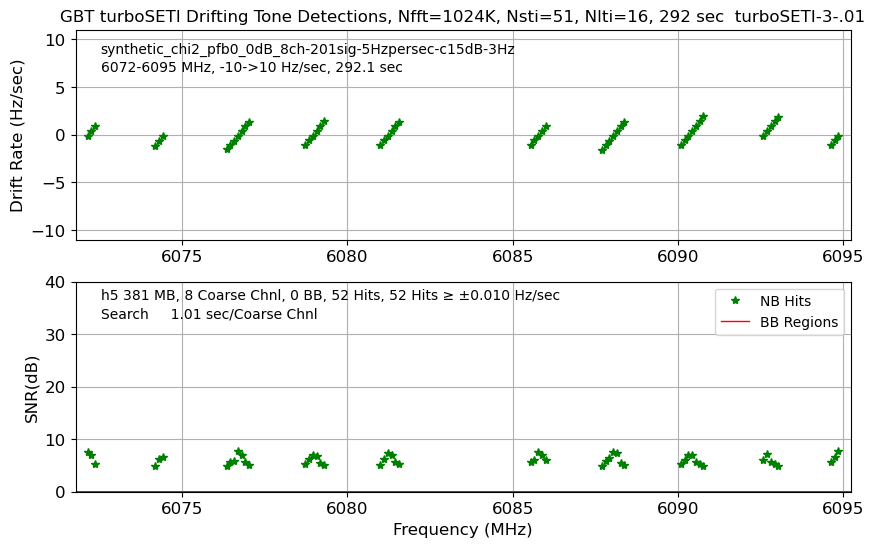

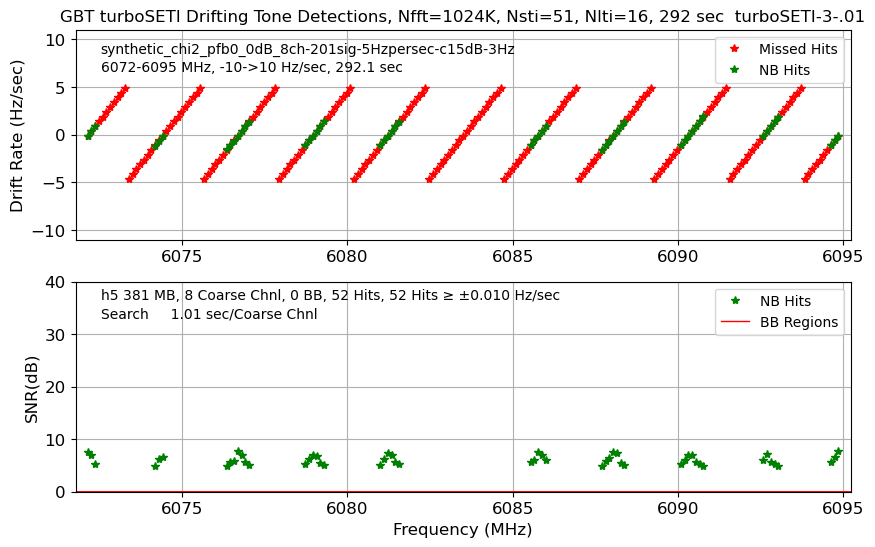

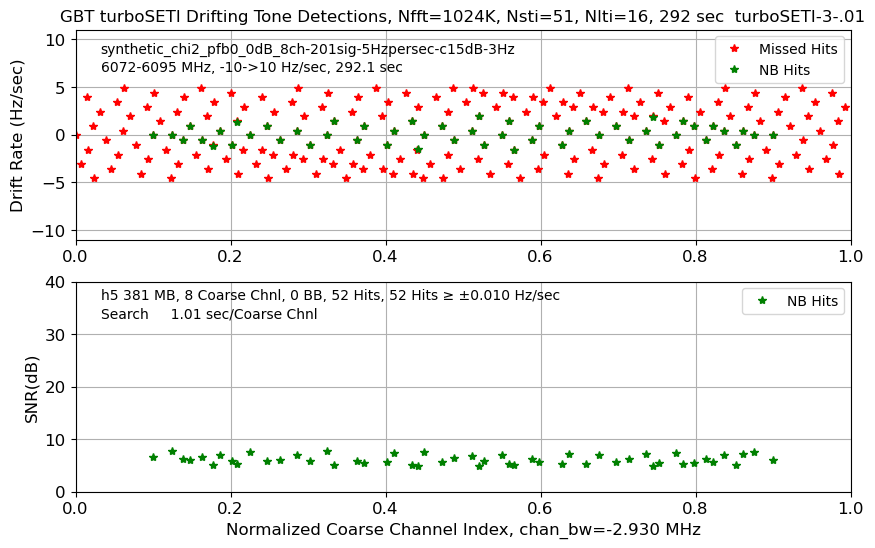

In [25]:
for i_drift_limit in range(n_drift_limit):

    min_abs_drift_Hz_sec = min_abs_drift_Hz_sec_list[i_drift_limit]

    # pare down detections according to min_abs_drift_Hz_sec

    if (n_det>0):
         # all NB dets with |drift| >= min_abs_drift_Hz_sec_list
        ii_NB= find((abs(det['drift_rate'])>=min_abs_drift_Hz_sec) &(det['f_delta_MHz']<=.01))
    else:
        ii_NB = []

    NB_det = select_det_cols(det,ii_NB)

    n_NB_det = NB_det['n_det']

    # add suffix to test_case
    
    if (min_abs_drift_Hz_sec<0.995):
        abs_drift_str = '-'+f'{min_abs_drift_Hz_sec:.2f}'[1:]
    else:
        abs_drift_str = '-'+f'{min_abs_drift_Hz_sec:.2f}'

    # do plots for narrowed drift range

    for i_ptype in range(4):

        f1_MHz = f_min_MHz
        f2_MHz = f_max_MHz
        max_abs_drift = max(abs(search_min_drift),abs(search_max_drift))
        drift1 = -max_abs_drift-1
        drift2 =  max_abs_drift+1
        line_width1 = 1
        line_width2 = 1
        x_limits=[f1_MHz,f2_MHz]
        x_label = 'Frequency (MHz)'
        if (i_ptype==0):
            continue    # skip for now
            fig_id = '06-'
            x_data1=[NB_det['f_center_MHz']]
            y_data1=[NB_det['drift_rate']]
            xy_markers1 = ['g*']
            xy_legend1 = []
            x_data2=[NB_det['f_center_MHz']]
            y_data2=[NB_det['snr_db']]
            xy_markers2 = ['g*']
            xy_legend2 = []
        elif (i_ptype==1):
            fig_id = '07-'
            x_data1=[NB_det['f_center_MHz']]
            y_data1=[NB_det['drift_rate']]
            xy_markers1 = ['g*']
            xy_legend1 = []
            x_data2=[NB_det['f_center_MHz'],f_dash]
            y_data2=[NB_det['snr_db'],BB_dash*.15]
            xy_markers2 = ['g*','r-']
            xy_legend2 = ['NB Hits','BB Regions']
        elif (i_ptype==2):
            if (h5_n_chirp==0):
                continue    # skip for now
            else:
                fig_id = '08-'
                x_data1=[h5_f_start,NB_det['f_center_MHz']]
                y_data1=[h5_drift_rate,NB_det['drift_rate']]
                xy_markers1 = ['r*','g*']
                xy_legend1 = [f'Missed Hits',f'NB Hits']
                x_data2=[NB_det['f_center_MHz'],f_dash]
                y_data2=[NB_det['snr_db'],BB_dash*.15]
                xy_markers2 = ['g*','r-']
                xy_legend2 = ['NB Hits','BB Regions']
        elif (i_ptype==3):
            if (plot_channel_idx_dets):
                fig_id = '09-'
                x_data1=[]
                x_data2=[]
                if (h5_n_chirp==0):
                    # no embedded test signals to plot
                    if (len(NB_det['ChanIndx'])>0):
                        x_data1=[NB_det['ChanIndx']/fine_fft_size]
                        x_data2=[NB_det['ChanIndx']/fine_fft_size]
                    y_data1=[NB_det['drift_rate']]
                    y_data2=[NB_det['snr_db']]
                    xy_markers1 = ['g*']
                    xy_legend1 = []
                    xy_markers2 = ['g*']
                    xy_legend2 = ['NB Hits']    
                else:
                    if (len(NB_det['ChanIndx'])>0):
                        x_data1=[h5_channel_idx/fine_fft_size,NB_det['ChanIndx']/fine_fft_size]
                        x_data2=[NB_det['ChanIndx']/fine_fft_size]
                    y_data1=[h5_drift_rate,NB_det['drift_rate']]
                    y_data2=[NB_det['snr_db']]
                    xy_markers1 = ['r*','g*']
                    xy_legend1 = [f'Missed Hits',f'NB Hits']                 
                    xy_markers2 = ['g*']
                    xy_legend2 = ['NB Hits']    
                x_limits=[0.,1.]
                x_label = f"Normalized Coarse Channel Index, chan_bw={p['chan_bw']*1e-6:.3f} MHz"
            else:
                continue    # skip for now
        
        %matplotlib inline
        fig = plt.figure(figsize=(10, 6))

        plt.subplot(2,1,1)

        fig_text_list1=[[.15,.84,input_file_stem],
                [.15,.81,f'{f_min_MHz:.0f}-{f_max_MHz:.0f} MHz, {search_min_drift:.0f}->{search_max_drift:.0f} Hz/sec, {t_obs:.1f} sec']]
        
        if (1):
            # plot drift rates on linear scale, pos & neg values
            pltg.plot_generic(fig=fig,x_data=x_data1,y_data=y_data1,xy_markers=xy_markers1,line_width=line_width1,xy_legend=xy_legend1,
                    x_limits=x_limits,
                    y_limits=[drift1,drift2],
                    x_label = [],
                    y_label = 'Drift Rate (Hz/sec)',
                    fig_title= telescope.upper() + ' '+search_app_string+' Drifting Tone Detections, ' + config_str + abs_drift_str,
                    fig_text_list=fig_text_list1)
        else:
            # plot drift rate magnitudes on log scale
            y_data1=[abs(NB_det['drift_rate'])]
            pltg.plot_generic(fig=fig,x_data=x_data1,y_data=y_data1,xy_markers=xy_markers1,line_width=line_width1,xy_legend=xy_legend1,
                    x_limits=x_limits,
                    y_limits=[min_abs_drift_Hz_sec/2,drift2*10],
                    x_label = [],
                    y_log = True,
                    y_label = 'abs(Drift Rate) (Hz/sec)',
                    fig_title= telescope.upper() + ' '+search_app_string+' Drifting Tone Detections, ' + config_str + abs_drift_str,
                    fig_text_list=fig_text_list1)
                
        plt.subplot(2,1,2)

        fig_text_list2=[[.15,.43,f'h5 {h5_size_MB:3.0f} MB, {n_coarse_channels} Coarse Chnl, {n_BB_det} BB, {n_NB_det0} Hits, '+
                        f'{n_NB_det} Hits \u2265 ±{min_abs_drift_Hz_sec:5.3f} Hz/sec'],
                        [.15,.40,f'Search    {t_search:5.2f} sec/Coarse Chnl']]

        pltg.plot_generic(fig=fig,x_data=x_data2,y_data=y_data2,xy_markers=xy_markers2,line_width=line_width2,xy_legend=xy_legend2,
                    x_limits=x_limits,
                    y_limits=[0., 40.],
                    x_label = x_label,
                    y_label = 'SNR(dB)',
                    fig_title= '',
                    fig_text_list=fig_text_list2,
                    legend_loc = 'upper right')

        plt.savefig(fig_dir + fig_id + fig_name_base+'-det-'+test_case+abs_drift_str+'.png',bbox_inches='tight')

        if (display_figs01 and (i_drift_limit==0)):
            plt.show()
        
        plt.close(fig)


In [26]:
            # x_data1=[NB_det1_out['f_center_MHz'],NB_det1_in['f_center_MHz']]
            # y_data1=[NB_det1_out['drift_rate'],NB_det1_in['drift_rate']]
            # xy_markers1 = ['g*','r*']
            # xy_legend1 = [f'Hits Outside BB ({n_NB_det1_out})',f'Hits Inside BB ({n_NB_det1_in})']
            # x_data2=[NB_det1_out['f_center_MHz'],NB_det1_in['f_center_MHz'],f_dash]
            # y_data2=[NB_det1_out['snr_db'],NB_det1_in['snr_db'],BB_dash*.15]
            # xy_markers2 = ['g*','r*','r-']
            # xy_legend2 = ['Hits Outside BB','Hits Inside BB','BB Regions']


In [27]:
t_e2e = time.time() - t_e2e_start
print(f'seti_h5_find_hits completed, {t_e2e:.2f} sec\n')
plt.close('all')

seti_h5_find_hits completed, 10.61 sec



In [28]:
if beep_when_h5_complete:
    try:
        # Beep in WSL
        if os.system("powershell.exe '[console]::beep(261.6,700)'") !=0:
            raise Exception('powershell.exe not found')
    except:
        # linux, probably doesn't work
        print('Beep!')
        os.system("echo -ne '\a'")